# Simple MusDis Inference

Load audio → Encode to latent → Extract structure/timbre → Reconstruct → Decode to audio

In [1]:
# Setup
import torch
import gin
import sys
from pathlib import Path
import os
import numpy as np
from IPython.display import display, Audio

# Add src to path
sys.path.append(str(Path.cwd().parent.parent / "src"))

import musdis
from music2latent import EncoderDecoder

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

# Initialize music2latent encoder/decoder
encdec = EncoderDecoder()
print("Music2latent encoder/decoder loaded")

/home/lauraibnz/Code/MusDis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Music2latent encoder/decoder loaded
Music2latent encoder/decoder loaded


In [2]:
import torch
import os
import gin

# --- Load model and EMA weights properly ---
model_path = "../runs/slakh2100_train_fix_dims_timbre_smaller"
config_path = os.path.join(model_path, "config.gin")
checkpoint_path = os.path.join(model_path, "best_model.pt")

gin.clear_config()
gin.parse_config_file(config_path)

from musdis.pipeline.model import DDPM
model = DDPM().to(device)

ckpt = torch.load(checkpoint_path, map_location=device)

# Prefer EMA weights if available
if "ema_state_dict" in ckpt:
    print("Loading EMA weights (for stable inference).")
    ema_state = ckpt["ema_state_dict"]
    sd = model.state_dict()
    for k, v in ema_state.items():
        if k in sd and sd[k].shape == v.shape:
            sd[k] = v
    model.load_state_dict(sd, strict=False)
else:
    print("No EMA found, loading regular model weights.")
    model.load_state_dict(ckpt["model_state_dict"], strict=False)

model.eval()

print(f"Model loaded from epoch {ckpt.get('epoch', 'N/A')}")


Loading EMA weights (for stable inference).
Model loaded from epoch 6


In [3]:
# Step 1: Load audio and latent from dataset
# Load dataset and get a sample using the SAME split as training
from musdis.dataset.dataset import BaseDataset
from musdis.pipeline.utils import create_dataloaders
import torch
import random

# Set the same random seed as training to ensure consistent splits
torch.manual_seed(42)  # Same seed as in train.py

dataset = BaseDataset("../dataset/babyslakh_16k/", return_latents=True)
print(f"Dataset size: {len(dataset)}")

# Use the same DataLoader creation as training (now fixed)
# This ensures we get the exact same train/val split as during training
train_loader, val_loader = create_dataloaders(
    dataset, 
    batch_size=1,      # Small batch for inference
    train_split=0.95,  # Same as default in utils
    num_workers=0      # No multiprocessing for simplicity
)

print(f"Train size: {len(train_loader.dataset)}, Val size: {len(val_loader.dataset)}")

# Choose your sample here - change this number to get different samples!
sample_idx = 4  # Change this to 0, 1, 2, 3, etc. for different samples

# Or use random sampling:
# sample_idx = random.randint(0, len(val_loader.dataset) - 1)

print(f"Using sample index: {sample_idx}")
sample = val_loader.dataset[sample_idx]

# Handle different tensor shapes robustly
if sample['audio'].dim() == 1:
    sample_audio = sample['audio'].numpy()
else:
    sample_audio = sample['audio'][0].numpy() if sample['audio'].shape[0] == 1 else sample['audio'].numpy()

if sample['latent'].dim() == 2:
    latent = sample['latent'].unsqueeze(0).to(device)
else:
    latent = sample['latent'][0].unsqueeze(0).to(device) if sample['latent'].shape[0] == 1 else sample['latent'].unsqueeze(0).to(device)

print(f"Audio shape: {sample_audio.shape}")
print(f"Pre-computed latent shape: {latent.shape}")

# Play original audio from validation set (16kHz sample rate)
print("Original audio from validation set (unseen during training):")
display(Audio(sample_audio, rate=16000))

Dataset size: 2832
Train size: 2690, Val size: 142
Using sample index: 4
Audio shape: (160000,)
Pre-computed latent shape: torch.Size([1, 64, 38])
Original audio from validation set (unseen during training):


In [4]:
# Step 2: Extract structure and timbre embeddings
# Ensure latent is in the correct dtype for the model
latent = latent.to(device=device, dtype=torch.float32)
print(f"Latent dtype: {latent.dtype}, device: {latent.device}")

with torch.no_grad():
    structure_embedding = model.encode_structure(latent)
    timbre_embedding = model.encode_timbre(latent)

if structure_embedding is not None:
    print(f"Structure embedding shape: {structure_embedding.shape}")  # Should preserve time
if timbre_embedding is not None:
    print(f"Timbre embedding shape: {timbre_embedding.shape}")        # Should be global

Latent dtype: torch.float32, device: cpu
Structure embedding shape: torch.Size([1, 48, 38])
Timbre embedding shape: torch.Size([1, 16])


In [5]:
# Step 3: Reconstruct latent using diffusion sampling
print("Reconstructing latent using diffusion sampling...")
print(model.posterior_mean_coef1.shape, model.posterior_mean_coef2.shape, model.posterior_variance.shape)

with torch.no_grad():
    reconstructed_latent = model.sample(
        time_source=latent,
        cond_source=latent, 
        num_inference_steps=1000
    )

print(f"Reconstructed latent shape: {reconstructed_latent.shape}")
print(f"Original std: {latent.std().item():.4f}, Reconstructed std: {reconstructed_latent.std().item():.4f}")
print(f"Original range: [{latent.min().item():.4f}, {latent.max().item():.4f}]")
print(f"Reconstructed range: [{reconstructed_latent.min().item():.4f}, {reconstructed_latent.max().item():.4f}]")

Reconstructing latent using diffusion sampling...
torch.Size([1000]) torch.Size([1000]) torch.Size([1000])
Reconstructed latent shape: torch.Size([1, 64, 38])
Original std: 1.3286, Reconstructed std: 1.5580
Original range: [-4.9805, 5.7773]
Reconstructed range: [-6.3196, 7.0168]
Reconstructed latent shape: torch.Size([1, 64, 38])
Original std: 1.3286, Reconstructed std: 1.5580
Original range: [-4.9805, 5.7773]
Reconstructed range: [-6.3196, 7.0168]


In [6]:
# Step 4: Decode latent back to audio
print("Decoding reconstructed latent back to audio...")

# Convert back to numpy for music2latent decoder
reconstructed_np = reconstructed_latent.cpu().numpy()
original_latent_np = latent.cpu().numpy()

# Decode both to audio
reconstructed_audio = encdec.decode(reconstructed_np)
original_latent_audio = encdec.decode(original_latent_np)

print(f"Reconstructed audio shape: {reconstructed_audio.shape}")
print(f"Original latent audio shape: {original_latent_audio.shape}")

# Play all audio for comparison (16kHz sample rate)
print("Audio comparison:")
print("1. Original audio from dataset:")
display(Audio(sample_audio, rate=16000))

print("2. Original pre-computed latent → decoded:")
display(Audio(original_latent_audio, rate=16000))

print("3. Diffusion reconstructed latent → decoded:")
display(Audio(reconstructed_audio, rate=16000))

Decoding reconstructed latent back to audio...
Reconstructed audio shape: torch.Size([1, 157184])
Original latent audio shape: torch.Size([1, 157184])
Audio comparison:
1. Original audio from dataset:
Reconstructed audio shape: torch.Size([1, 157184])
Original latent audio shape: torch.Size([1, 157184])
Audio comparison:
1. Original audio from dataset:


2. Original pre-computed latent → decoded:


3. Diffusion reconstructed latent → decoded:


In [7]:
# Step 5: Quality check - latent space reconstruction
import torch.nn.functional as F

with torch.no_grad():
    mse_loss = F.mse_loss(reconstructed_latent, latent)
    print(f"Latent reconstruction MSE: {mse_loss.item():.6f}")
    print("(Lower MSE indicates better reconstruction quality)")

Latent reconstruction MSE: 0.214010
(Lower MSE indicates better reconstruction quality)


In [8]:
# Detailed MSE analysis over time
import torch.nn.functional as F

with torch.no_grad():
    # Overall MSE
    mse_loss = F.mse_loss(reconstructed_latent, latent)
    print(f"Overall latent reconstruction MSE: {mse_loss.item():.6f}")
    
    # MSE over time dimension (last dimension is time with 38 timesteps)
    print("\nMSE values over time:")
    print("Time step | MSE")
    print("-" * 20)
    
    # Print first 5 time steps
    for t in range(min(5, latent.shape[-1])):
        time_slice_mse = F.mse_loss(reconstructed_latent[:, :, t], latent[:, :, t])
        print(f"{t:2d}       | {time_slice_mse.item():.6f}")
    
    # Print ellipsis if there are more than 10 total time steps
    if latent.shape[-1] > 10:
        print("...      | ...")
    
    # Print last 5 time steps
    start_idx = max(5, latent.shape[-1] - 5)
    for t in range(start_idx, latent.shape[-1]):
        time_slice_mse = F.mse_loss(reconstructed_latent[:, :, t], latent[:, :, t])
        print(f"{t:2d}       | {time_slice_mse.item():.6f}")
    
    # Also compute average MSE for first half vs second half
    mid_point = latent.shape[-1] // 2
    first_half_mse = F.mse_loss(reconstructed_latent[:, :, :mid_point], latent[:, :, :mid_point])
    second_half_mse = F.mse_loss(reconstructed_latent[:, :, mid_point:], latent[:, :, mid_point:])
    
    print(f"\nFirst half (0-{mid_point-1}) MSE: {first_half_mse.item():.6f}")
    print(f"Second half ({mid_point}-{latent.shape[-1]-1}) MSE: {second_half_mse.item():.6f}")
    print(f"Ratio (second/first): {(second_half_mse/first_half_mse).item():.2f}")

Overall latent reconstruction MSE: 0.214010

MSE values over time:
Time step | MSE
--------------------
 0       | 0.148706
 1       | 0.145098
 2       | 0.137798
 3       | 0.222442
 4       | 0.181340
...      | ...
33       | 0.435093
34       | 0.206754
35       | 0.170624
36       | 0.164472
37       | 0.239213

First half (0-18) MSE: 0.218686
Second half (19-37) MSE: 0.209335
Ratio (second/first): 0.96


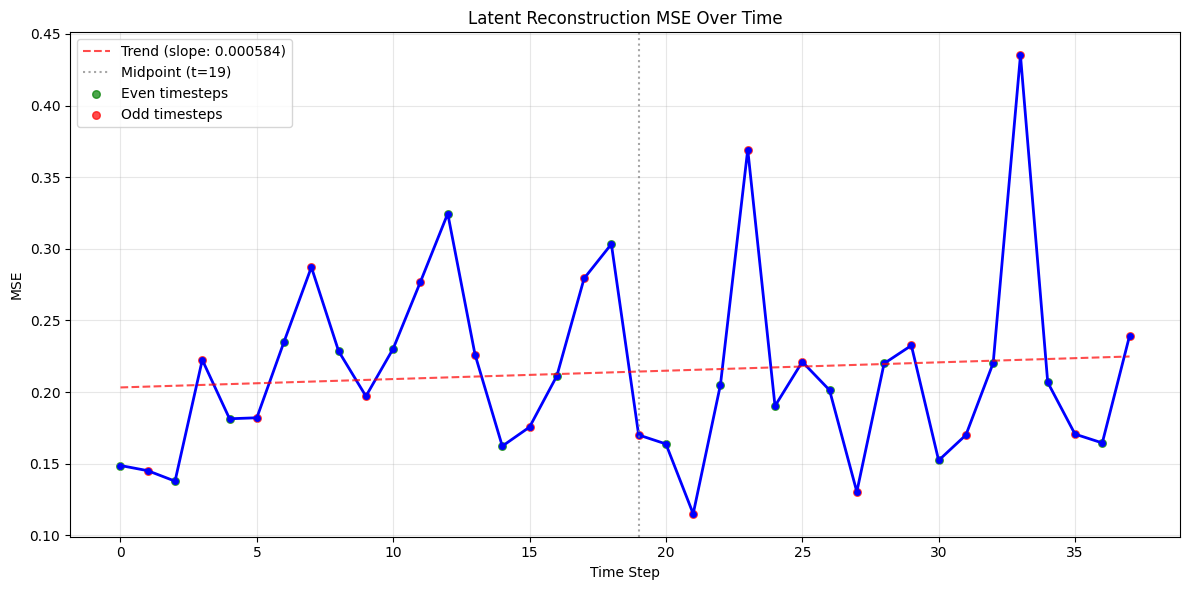

MSE trend slope: 0.000584 (positive = getting worse over time)
Mean MSE first half: 0.218686
Mean MSE second half: 0.209335
Max MSE: 0.435093 at time step 33
Min MSE: 0.115003 at time step 21

Even timesteps average MSE: 0.204597
Odd timesteps average MSE: 0.223423
Odd/Even ratio: 1.092
✅ No strong alternating pattern detected.


In [9]:
# Plot MSE values over time
import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    # Calculate MSE for each time step
    time_steps = list(range(latent.shape[-1]))
    mse_values = []
    
    for t in range(latent.shape[-1]):
        time_slice_mse = F.mse_loss(reconstructed_latent[:, :, t], latent[:, :, t])
        mse_values.append(time_slice_mse.item())
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(time_steps, mse_values, 'b-', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Time Step')
    plt.ylabel('MSE')
    plt.title('Latent Reconstruction MSE Over Time')
    plt.grid(True, alpha=0.3)
    
    # Add a trend line to see if there's a clear pattern
    z = np.polyfit(time_steps, mse_values, 1)
    p = np.poly1d(z)
    plt.plot(time_steps, p(time_steps), 'r--', alpha=0.7, label=f'Trend (slope: {z[0]:.6f})')
    
    # Highlight first and second half
    mid_point = len(time_steps) // 2
    plt.axvline(x=mid_point, color='gray', linestyle=':', alpha=0.7, label=f'Midpoint (t={mid_point})')
    
    # Color alternating pattern if it exists
    even_indices = [i for i in range(0, len(time_steps), 2)]
    odd_indices = [i for i in range(1, len(time_steps), 2)]
    even_values = [mse_values[i] for i in even_indices]
    odd_values = [mse_values[i] for i in odd_indices]
    
    plt.scatter(even_indices, even_values, color='green', alpha=0.7, s=30, label='Even timesteps')
    plt.scatter(odd_indices, odd_values, color='red', alpha=0.7, s=30, label='Odd timesteps')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"MSE trend slope: {z[0]:.6f} (positive = getting worse over time)")
    print(f"Mean MSE first half: {np.mean(mse_values[:mid_point]):.6f}")
    print(f"Mean MSE second half: {np.mean(mse_values[mid_point:]):.6f}")
    print(f"Max MSE: {max(mse_values):.6f} at time step {mse_values.index(max(mse_values))}")
    print(f"Min MSE: {min(mse_values):.6f} at time step {mse_values.index(min(mse_values))}")
    
    # Check for even/odd alternating pattern
    even_mse_avg = np.mean(even_values)
    odd_mse_avg = np.mean(odd_values)
    print(f"\nEven timesteps average MSE: {even_mse_avg:.6f}")
    print(f"Odd timesteps average MSE: {odd_mse_avg:.6f}")
    print(f"Odd/Even ratio: {odd_mse_avg/even_mse_avg:.3f}")
    
    if odd_mse_avg > even_mse_avg * 1.2:
        print("🔥 Strong alternating pattern detected! Odd timesteps are much worse.")
    elif even_mse_avg > odd_mse_avg * 1.2:
        print("🔄 Reverse alternating pattern! Even timesteps are worse.")
    else:
        print("✅ No strong alternating pattern detected.")

# Embedding Analysis & Debugging

Let's investigate the conditioning embeddings in detail to understand potential issues.

In [10]:
# Simple conditioning analysis - just the basics
print("=== BASIC CONDITIONING ANALYSIS ===")

with torch.no_grad():
    # Get conditioning embeddings using separate methods
    struct_emb = model.encode_structure(latent)
    timbre_emb = model.encode_timbre(latent)
    
    print("1. EMBEDDING STATISTICS:")
    print(f"   Structure: shape={struct_emb.shape}, mean={struct_emb.mean().item():.4f}, std={struct_emb.std().item():.4f}")
    print(f"   Timbre: shape={timbre_emb.shape}, mean={timbre_emb.mean().item():.4f}, std={timbre_emb.std().item():.4f}")
    print(f"   Magnitude ratio (struct/timbre): {torch.norm(struct_emb).item() / torch.norm(timbre_emb).item():.2f}")
    
    print("\n2. UNET CONDITIONING TEST:")
    # Test if conditioning actually changes UNet output
    test_noise = torch.randn_like(latent)
    test_timesteps = torch.randint(0, 100, (1,), device=device)
    
    # Create zero conditioning tensors of the correct shapes (instead of None)
    zero_timbre = torch.zeros_like(timbre_emb)
    zero_struct = torch.zeros_like(struct_emb)
    
    # Compare outputs with actual conditioning vs zero conditioning
    output_with_cond = model.net(test_noise, test_timesteps, cond=timbre_emb, time_cond=struct_emb)
    output_no_cond = model.net(test_noise, test_timesteps, cond=zero_timbre, time_cond=zero_struct)
    
    conditioning_diff = torch.norm(output_with_cond - output_no_cond).item()
    print(f"   UNet output difference with real vs zero conditioning: {conditioning_diff:.4f}")
    
    if conditioning_diff < 0.01:
        print("   ❌ Conditioning has almost no effect on UNet!")
    else:
        print("   ✅ Conditioning is affecting UNet output")
    
    print("\n3. INDIVIDUAL CONDITIONING EFFECTS:")
    output_timbre_only = model.net(test_noise, test_timesteps, cond=timbre_emb, time_cond=zero_struct)
    output_struct_only = model.net(test_noise, test_timesteps, cond=zero_timbre, time_cond=struct_emb)
    
    timbre_effect = torch.norm(output_timbre_only - output_no_cond).item()
    struct_effect = torch.norm(output_struct_only - output_no_cond).item()
    
    print(f"   Timbre-only effect: {timbre_effect:.4f}")
    print(f"   Structure-only effect: {struct_effect:.4f}")
    print(f"   Structure dominance ratio: {struct_effect/timbre_effect:.1f}x" if timbre_effect > 0 else "   Structure dominance: ∞ (timbre has no effect)")

print("\nDONE! This tells us if both embeddings are working and their relative influence.")

=== BASIC CONDITIONING ANALYSIS ===
1. EMBEDDING STATISTICS:
   Structure: shape=torch.Size([1, 48, 38]), mean=0.0813, std=1.1405
   Timbre: shape=torch.Size([1, 16]), mean=-0.3397, std=2.8215
   Magnitude ratio (struct/timbre): 4.43

2. UNET CONDITIONING TEST:
   UNet output difference with real vs zero conditioning: 135.6734
   ✅ Conditioning is affecting UNet output

3. INDIVIDUAL CONDITIONING EFFECTS:
   Timbre-only effect: 16.7941
   Structure-only effect: 133.6917
   Structure dominance ratio: 8.0x

DONE! This tells us if both embeddings are working and their relative influence.


# Timbre Transfer Experiment

Simple test: Extract structure from one sample and timbre from another, then combine them.

In [11]:
# Timbre transfer: Use reconstruction sample + one new sample
print("=== TIMBRE TRANSFER ===")

# Reuse the sample from reconstruction experiment (sample A)
audio_a = sample_audio
latent_a = latent
sample_a_idx = sample_idx

# Load a different sample (sample B)
sample_b_idx = 7  # Different from reconstruction sample
sample_b = val_loader.dataset[sample_b_idx]

# Process sample B
if sample_b['audio'].dim() == 1:
    audio_b = sample_b['audio'].numpy()
else:
    audio_b = sample_b['audio'][0].numpy() if sample_b['audio'].shape[0] == 1 else sample_b['audio'].numpy()

if sample_b['latent'].dim() == 2:
    latent_b = sample_b['latent'].unsqueeze(0).to(device, dtype=torch.float32)
else:
    latent_b = sample_b['latent'][0].unsqueeze(0).to(device, dtype=torch.float32) if sample_b['latent'].shape[0] == 1 else sample_b['latent'].unsqueeze(0).to(device, dtype=torch.float32)

print(f"Sample A (from reconstruction): Index {sample_a_idx}")
print(f"Sample B (new): Index {sample_b_idx}")

# Generate both timbre transfer combinations
with torch.no_grad():
    # Combination 1: A's structure + B's timbre
    hybrid_ab = model.sample(
        time_source=latent_a,
        cond_source=latent_b,  # B's characteristics
        num_inference_steps=100
    )
    
    # Combination 2: B's structure + A's timbre  
    hybrid_ba = model.sample(
        time_source=latent_b,
        cond_source=latent_a,  # A's characteristics
        num_inference_steps=100
    )

# Decode all audio
hybrid_ab_audio = encdec.decode(hybrid_ab.cpu().numpy())
hybrid_ba_audio = encdec.decode(hybrid_ba.cpu().numpy())

# Play all 4 audio samples
print("\n🎵 Original Sample A (reconstruction sample):")
display(Audio(audio_a, rate=16000))

print("🎵 Original Sample B:")  
display(Audio(audio_b, rate=16000))

print("🎵 Hybrid 1: A's structure + B's timbre:")
display(Audio(hybrid_ab_audio, rate=16000))

print("🎵 Hybrid 2: B's structure + A's timbre:")
display(Audio(hybrid_ba_audio, rate=16000))

=== TIMBRE TRANSFER ===
Sample A (from reconstruction): Index 4
Sample B (new): Index 7

🎵 Original Sample A (reconstruction sample):

🎵 Original Sample A (reconstruction sample):


🎵 Original Sample B:


🎵 Hybrid 1: A's structure + B's timbre:


🎵 Hybrid 2: B's structure + A's timbre:
